In [14]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import os
from datetime import datetime, timedelta
import pandas as pd
import math
import numpy as np
import random
from tqdm import trange

from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile

from math import sqrt
from scipy import stats

import matplotlib
# matplotlib.use('TkAgg')  # Switch to the TkAgg backend
import matplotlib.pyplot as plt
import datetime as dt

import torch
import torch.nn as nn
import time

import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [15]:
global save_path
name_sales = 'sales_train_evaluation.csv'
name_calendar = 'calendar.csv'
name_prices = 'sell_prices.csv'
save_name = 'M5'
window_size = 192
stride_size = 1
num_covariates = 6
train_start = '2011-01-29 00:00:00'
train_end = '2016-04-24 00:00:00'
test_start = '2016-04-25 00:00:00' #need additional 7 days as given info
test_end = '2016-05-22 00:00:00'
pred_days = 28
given_days = 7

In [16]:
save_path = os.path.join('data', save_name)
if not os.path.exists(save_path):
    os.makedirs(save_path)
sales_csv_path = os.path.join(save_path, name_sales)
calendar_csv_path = os.path.join(save_path, name_calendar)
prices_csv_path = os.path.join(save_path, name_prices)

sales = pd.read_csv('../../data/M5/sales_train_evaluation.csv')
sales.name = 'sales'
calendar = pd.read_csv('../../data/M5/calendar.csv')
calendar.name = 'calendar'
prices = pd.read_csv('../../data/M5/sell_prices.csv')
prices.name = 'prices'

#Create date index
date_index = calendar['date']
dates = date_index[0:1941]
dates_list = [dt.datetime.strptime(date, '%Y-%m-%d').date() for date in dates]

# Create a data frame for items sales per day with item ids (with Store Id) as columns names  and dates as the index 
sales['item_store_id'] = sales.apply(lambda x: x['item_id']+'_'+x['store_id'],axis=1)
data_frame = sales.loc[:,'d_1':'d_1941'].T
data_frame.columns = sales['item_store_id'].values

#Set Dates as index 
data_frame = pd.DataFrame(data_frame).set_index([dates_list])
data_frame.index = pd.to_datetime(data_frame.index)
data_frame.head()

data_frame.shape

(1941, 30490)

In [17]:
def gen_m5_covariates(calendar_df, sales_df):
    # Assuming calendar_df is the calendar DataFrame and sales_df is the sales data DataFrame
    num_covariates = 6  # Example: day of week, month, SNAP_CA, SNAP_TX, SNAP_WI, event
    times = pd.to_datetime(calendar_df['date'])
    covariates = np.zeros((len(times), num_covariates))
    # Day of week and month as numerical values
    covariates[:, 0] = times.dt.dayofweek
    covariates[:, 1] = times.dt.month
    # SNAP days for CA, TX, and WI
    covariates[:, 2] = calendar_df['snap_CA']
    covariates[:, 3] = calendar_df['snap_TX']
    covariates[:, 4] = calendar_df['snap_WI']
    # Event (simple binary indicator for this example)
    covariates[:, 5] = calendar_df[['event_name_1', 'event_name_2']].notnull().any(axis=1).astype(int)
    # Standardize covariates (optional depending on model requirements)
    for i in range(num_covariates):
        covariates[:, i] = (covariates[:, i] - covariates[:, i].mean()) / covariates[:, i].std()
    return covariates

In [18]:
covariates = gen_m5_covariates(calendar, sales)
train_data = data_frame[train_start:train_end].values
test_data = data_frame[test_start:test_end].values
data_start = (train_data!=0).argmax(axis=0) #find first nonzero value in each time series
total_time = data_frame.shape[0] #1941 (days)
num_series = data_frame.shape[1] #30490 (item_id)
covariates = covariates[:1941,:]

In [19]:
new = data_frame.values
b = new[:, :, np.newaxis]
c = covariates[:,np.newaxis,:]
# Broadcast c to match the shape of b along the last axis
c_broadcasted = np.broadcast_to(c, (1941, 30490, 6))

# Concatenate b and c along the last axis to create the new array
dataset = np.concatenate((b, c_broadcasted), axis=-1)

# Slice the array to get the desired shape (1491, 30490, 7)
dataset = dataset[:1941, :, :]
dataset = np.swapaxes(dataset,0,1)

print(dataset.shape)  # Output: (1491, 30490, 7)

(30490, 1941, 7)


In [20]:
# if window is 100 and prediction step is 1
# in -> [0..99]
# target -> [1..100]

'''
In fact, assuming that the number of samples is N, 
the length of the input sequence is m, and the backward prediction is k steps, 
then length of a block [input : 1 , 2 ... m  -> output : k , k+1....m+k ] 
should be (m+k) :  block_len, so to ensure that each block is complete, 
the end element of the last block should be the end element of the entire sequence, 
so the actual number of blocks is [N - block_len + 1] 
'''

def create_inout_sequences(input_data, pred_len, window_size, stride_size):
    train_X = []
    train_y = []
    L = len(input_data)
    # print('L:',L)
    block_num =  (L - window_size  - pred_len + 1) // stride_size
    # print('block_num:',block_num)

    for i in range(block_num):
        train_seq = input_data[i * stride_size : i * stride_size + window_size]
        train_label = input_data[i * stride_size + window_size : i * stride_size + window_size + pred_len,0]
        # print(train_label.shape)
        train_X.append(train_seq)
        train_y.append(train_label)

    # print(len(train_y))
    return train_X, train_y

def get_data(train_data, test_data, pred_len, window_size, device, stride_size):
   
    # train_data = dataset[:train_end]
    # test_data = dataset[test_start:]
    # print('train_data:',len(train_data))
    # print('test_data:',len(test_data))

    train_X, train_y = create_inout_sequences(train_data, pred_len, window_size, stride_size)
    train_X = torch.FloatTensor(train_X)
    train_y = torch.FloatTensor(train_y)

    test_X, test_y = create_inout_sequences(test_data, pred_len, window_size, stride_size)
    test_X = torch.FloatTensor(test_X)
    test_y = torch.FloatTensor(test_y)

    return train_X.to(device),train_y.to(device),test_X.to(device),test_y.to(device)


In [31]:
total_len = 1941
train_end = 1913
window_size = 196
pred_len = 28
test_start = train_end - window_size
batch_size = 10
stride_size = 1
# print('test_start:',test_start)
# print(len(dataset[0]))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from sklearn.preprocessing import MinMaxScaler, StandardScaler

class MinMaxScaler3D(MinMaxScaler):

    def fit_transform(self, X, y=None):
        x = np.reshape(X, newshape=(X.shape[0]*X.shape[1], X.shape[2]))
        return np.reshape(super().fit_transform(x, y=y), newshape=X.shape)
    def transform(self, X):
        x = np.reshape(X, newshape=(-1, X.shape[-1]))  # Flatten all dimensions except the last one
        return np.reshape(super().transform(x), newshape=X.shape)


# input_data = dataset[0,:,:]
input_data = dataset[0,:,:]
train_data = input_data[:train_end]
test_data = input_data[test_start:]

# scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_X = StandardScaler()
train_data = scaler_X.fit_transform(train_data)
test_data = scaler_X.transform(test_data)
 
train_X, train_y, test_X, test_y = get_data(train_data, test_data, pred_len, window_size, device, stride_size)


# scaler_X = MinMaxScaler3D()
# train_X = scaler_X.fit_transform(train_X)
# test_X = scaler_X.transform(test_X)

# scaler_y = StandardScaler()
# train_y = scaler_y.fit_transform(train_y)


# Define batch size
batch_size = 10


# Convert NumPy arrays to PyTorch tensors
train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
train_y_tensor = torch.tensor(train_y, dtype=torch.float32)
test_X_tensor = torch.tensor(test_X, dtype=torch.float32)
test_y_tensor = torch.tensor(test_y, dtype=torch.float32)

# Create TensorDataset and DataLoader for batching
train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(test_X_tensor, test_y_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)


print(train_X.shape)
print(train_y.shape)


torch.Size([1690, 196, 7])
torch.Size([1690, 28])


/var/folders/ct/9f006jjj4_s3bt3mcwlfd_d80000gn/T/ipykernel_63319/2398248087.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
/var/folders/ct/9f006jjj4_s3bt3mcwlfd_d80000gn/T/ipykernel_63319/2398248087.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y_tensor = torch.tensor(train_y, dtype=torch.float32)
/var/folders/ct/9f006jjj4_s3bt3mcwlfd_d80000gn/T/ipykernel_63319/2398248087.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_X_tensor = torch.tensor(test_X, 

In [32]:
train_y

tensor([[-0.4578, -0.4578, -0.4578,  ..., -0.4578, -0.4578, -0.4578],
        [-0.4578, -0.4578, -0.4578,  ..., -0.4578, -0.4578, -0.4578],
        [-0.4578, -0.4578, -0.4578,  ..., -0.4578, -0.4578, -0.4578],
        ...,
        [ 1.0019,  1.0019,  1.0019,  ...,  1.0019,  3.9213, -0.4578],
        [ 1.0019,  1.0019, -0.4578,  ...,  3.9213, -0.4578,  1.0019],
        [ 1.0019, -0.4578, -0.4578,  ..., -0.4578,  1.0019,  1.0019]])

In [24]:
# # no transformer
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset

# # Define the Transformer model
# class TransformerModel(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(TransformerModel, self).__init__()
#         self.input_dim = input_dim
#         self.output_dim = output_dim
#         # Define the transformer layers, encoder, and decoder here
#         self.transformer_layers = nn.Sequential(
#             # Add your transformer layers here
#             nn.Linear(input_dim, 256),
#             nn.ReLU(),
#             nn.Linear(256, output_dim)
#         )
        
#     def forward(self, x):
#         # Implement the forward pass logic here
#         output_probs = self.transformer_layers(x)
#         predicted_demand = torch.argmax(output_probs, dim=1)
#         return self.transformer_layers(x)
    

# # Initialize the Transformer model
# input_dim = train_X.size(2)
# output_dim = train_y.size(1)
# model = TransformerModel(input_dim, output_dim)

# # Define your loss function and optimizer
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# # Training loop
# epochs = 10
# for epoch in range(epochs):
#     for batch_X, batch_y in train_loader:
#         print(batch_X.shape, batch_y.shape)
#         optimizer.zero_grad()
#         output = model(batch_X)
#         # output = model(batch_X)
#         output = output[:, 0, :]  # Keep only the first 224 elements along the second dimension
        
#         # print(output.shape)

#         # Compute the MSE loss
#         loss = criterion(output, batch_y)

#         loss.backward()
#         optimizer.step()
    
#     print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item()}')

# After training, you can use the model for predictions


In [22]:
# # transformer document + gpt

# # Define the parameters for the Transformer model
# d_model = 196  # Adjust the embedding dimension as needed
# nhead = 28  # Number of attention heads
# num_encoder_layers = 12  # Number of encoder layers
# dim_feedforward = 512  # Dimension of the feedforward network
# dropout = 0.1  # Dropout rate

# # Ensure d_model is divisible by nhead
# assert d_model % nhead == 0, "d_model must be divisible by nhead"

# # Initialize the Transformer model with the adjusted parameters
# transformer_model = nn.Transformer(d_model=d_model, nhead=nhead, num_encoder_layers=num_encoder_layers,
#                                    dim_feedforward=dim_feedforward, dropout=dropout)

# # Define batch size
# batch_size = 10

# # Create TensorDataset and DataLoader for batching
# train_dataset = TensorDataset(train_X, train_y)
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

# # Define your loss function and optimizer
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.001)

# # Training loop
# epochs = 10
# for epoch in range(epochs):
#     for batch_X, batch_y in train_loader:
#         optimizer.zero_grad()
        
#         # Ensure both batch_X and batch_y have the same feature dimension (d_model)
#         batch_y = batch_y.unsqueeze(2).expand(-1, -1, d_model // nhead)
#         batch_y = batch_y.transpose(0, 1)
#         batch_X = batch_X.transpose(0, 1)
        
#         # Forward pass through the Transformer model
#         output = transformer_model(batch_X, batch_y)
#         output = output[:, 0, :]  # Keep only the first 224 elements along the second dimension
        
#         # Compute the MSE loss
#         loss = criterion(output, batch_y)
        
#         # Backward pass and optimization step
#         loss.backward()
#         optimizer.step()
    
#     print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item()}')


In [33]:
import torch
import torch.nn as nn
import numpy as np
import time
import math
from matplotlib import pyplot

torch.manual_seed(0)
np.random.seed(0)

# S is the source sequence length
# T is the target sequence length
# N is the batch size
# E is the feature number

#src = torch.rand((10, 32, 512)) # (S,N,E) 
#tgt = torch.rand((20, 32, 512)) # (T,N,E)
#out = transformer_model(src, tgt)

input_window = 196 # number of input steps
output_window = 28 # number of prediction steps, in this model its fixed to one
block_len = input_window + output_window # for one input-output pir
batch_size = 10
# train_size = 0.8
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Positional Encoding for Transformer
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)
          

# Model definition using Transformer
class TransformerModel(nn.Module):
    def __init__(self, input_dim=7, d_model=512, nhead=8, num_layers=6, dropout=0.2):
        super(TransformerModel, self).__init__()

        self.encoder = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model, nhead)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.decoder = nn.Linear(d_model, 28)

    def forward(self, x):
        x = self.encoder(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = self.decoder(x[:, -28, :])
        return x

model = TransformerModel().to(device)


In [34]:
# Train the model
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3, verbose=True)

epochs = 10
early_stop_count = 0
min_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        x_batch, y_batch = batch
        # x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        # print(y_batch)
        # print(outputs)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            # x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            # print(outputs)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())

    val_loss = np.mean(val_losses)
    scheduler.step(val_loss)

    if val_loss < min_val_loss:
        min_val_loss = val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1

    if early_stop_count >= 8:
        print("Early stopping!")
        break

    print(f"Epoch {epoch + 1}/{epochs}, Validation Loss: {val_loss:.4f}")

Epoch 1/10, Validation Loss: 5.5933
Epoch 2/10, Validation Loss: 4.9870
Epoch 3/10, Validation Loss: 4.7228
Epoch 4/10, Validation Loss: 5.0241
Epoch 5/10, Validation Loss: 5.0620
Epoch 6/10, Validation Loss: 4.7382
Epoch 00007: reducing learning rate of group 0 to 5.0000e-05.
Epoch 7/10, Validation Loss: 5.3805
Epoch 8/10, Validation Loss: 5.0691
Epoch 9/10, Validation Loss: 4.8356
Epoch 10/10, Validation Loss: 5.0596


tensor([-0.4578, -0.4578, -0.4578,  2.4616, -0.4578,  3.9213,  6.8407, -0.4578,
        -0.4578,  1.0019,  1.0019, -0.4578,  2.4616,  1.0019,  2.4616,  2.4616,
         1.0019, -0.4578,  2.4616,  5.3810, -0.4578, -0.4578, -0.4578, -0.4578,
         3.9213,  3.9213, -0.4578,  1.0019])


<Axes: >

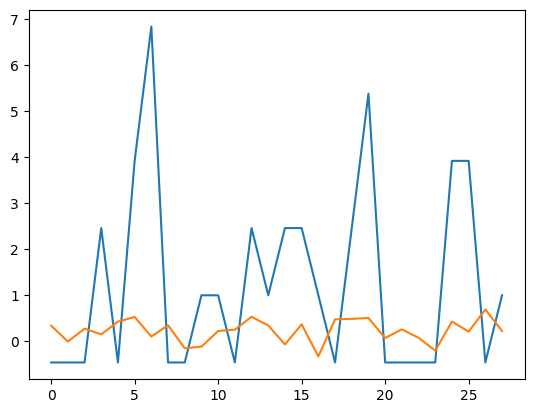

In [47]:
# Evaluation
model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        x_batch, y_batch = batch
        x_batch = x_batch.to(device)
        outputs = model(x_batch)
        # print(y_batch)
        # print(outputs)
        predictions.extend(outputs.squeeze().tolist())
    
print(y_batch[0])
data_array = y_batch[0].numpy()

sns.lineplot(y_batch[0])
sns.lineplot(predictions)


# rmse = np.sqrt(np.mean((scaler.inverse_transform(np.array(predictions).reshape(-1, 1)) - scaler.inverse_transform(y_test.numpy().reshape(-1, 1)))**2))
# print(f"Score (RMSE): {rmse:.4f}")

<Axes: >

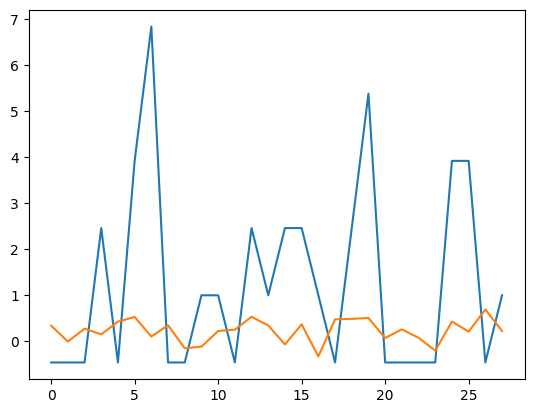

In [38]:
sns.lineplot(test_y[0])
sns.lineplot(predictions)

In [27]:
# Evaluation
model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        x_batch, y_batch = batch
        x_batch = x_batch.to(device)
        outputs = model(x_batch)
        predictions.append(outputs)

# Assuming predictions_flat, test_y_flat are 1D arrays
predictions_flat = torch.cat(predictions).cpu().numpy().flatten()
test_y_flat = test_y.numpy().flatten()

# Compute RMSE using NumPy operations
predictions_inv = scaler_y.inverse_transform(predictions_flat.reshape(-1, 1)).flatten()
test_y_inv = scaler_y.inverse_transform(test_y_flat.reshape(-1, 1)).flatten()

rmse = np.sqrt(np.mean((predictions_inv - test_y_inv)**2))
print(f"Score (RMSE): {rmse:.4f}")

NameError: name 'scaler_y' is not defined

In [ ]:
def train(train_data, scheduler, train_loader, optimizer, epochs):
    model.train() # Turn on the train mode \o/
    total_loss = 0.
    start_time = time.time()


    batch = 0
    for batch_X, batch_y in train_loader:
        # data and target are the same shape with (input_window,batch_len,1)
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.7)
        optimizer.step()

        total_loss += loss.item()
        log_interval = int(len(train_data) / batch_size / 5)
        if batch % log_interval == 0 and batch > 0:
            cur_loss = total_loss / log_interval
            elapsed = time.time() - start_time
            print('| epoch {:3d} | {:5d}/{:5d} batches | '
                  'lr {:02.6f} | {:5.2f} ms | '
                  'loss {:5.5f} | ppl {:8.2f}'.format(
                    epoch, batch, len(train_data) // batch_size, scheduler.get_lr()[0],
                    elapsed * 1000 / log_interval,
                    cur_loss, math.exp(cur_loss)))
            total_loss = 0
            start_time = time.time()
        batch += 1

In [ ]:
model = TransAm().to(device)

criterion = nn.MSELoss()
lr = 0.005 
#optimizer = torch.optim.SGD(model.parameters(), lr=lr)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.95)

best_val_loss = float("inf")
epochs = 10 # The number of epochs
best_model = None

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(train_data, scheduler, train_loader, optimizer, epochs)
    # if ( epoch % 5 == 0 ):
    #     val_loss = plot_and_loss(model, val_data,epoch)
    #     predict_future(model, val_data,200)
    # else:
    #     val_loss = evaluate(model, val_data)
   
    # print('-' * 89)
    # print('| end of epoch {:3d} | time: {:5.2f}s | valid loss {:5.5f} | valid ppl {:8.2f}'.format(epoch, (time.time() - epoch_start_time),
    #                                  val_loss, math.exp(val_loss)))
    # print('-' * 89)

    #if val_loss < best_val_loss:
    #    best_val_loss = val_loss
    #    best_model = model

    scheduler.step() 

#src = torch.rand(input_window, batch_size, 1) # (source sequence length,batch size,feature number) 
#out = model(src)
#
#print(out)
#print(out.shape)

In [ ]:
# Assuming predictions and test_y are tensors or arrays with the same shape
# Convert them to numpy arrays for plotting
predictions_np = predictions[0].detach().numpy()
test_y_np = test_y[0].detach().numpy()
plt.figure(figsize=(30,10))

# Create a line plot using Seaborn
sns.lineplot(data=predictions_np, label='Predictions')
sns.lineplot(data=test_y_np, label='Actual')

# Set plot labels and title
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.title('Predictions vs Actual')

# Show the legend
plt.legend()

# Show the plot
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super(TransformerEncoderLayer, self).__init__()
        self.self_attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)
        self.linear1 = nn.Linear(embed_dim, 512)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(512, embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x_normalized = self.norm1(x.transpose(0, 1)).transpose(0, 1)  # Transpose for layer normalization
        attention_output, _ = self.self_attention(x_normalized, x_normalized, x_normalized)
        x = x + self.dropout(attention_output)
        x_normalized = self.norm2(x.transpose(0, 1)).transpose(0, 1)  # Transpose for layer normalization
        x = x + self.dropout(self.linear2(nn.functional.relu(self.linear1(x_normalized))))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_layers, num_heads, dropout=0.1):
        super(TransformerEncoder, self).__init__()
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(embed_dim, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

class TransformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, num_layers=6, num_heads=8, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.embed_dim = 256  # Adjust this value based on your requirements
        self.encoder = TransformerEncoder(self.embed_dim, num_layers, num_heads, dropout=dropout)
        self.decoder = nn.Linear(self.embed_dim, output_dim)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    
# Define batch size
batch_size = 10

# Create TensorDataset and DataLoader for batching
train_dataset = TensorDataset(train_X, train_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize the Transformer model
input_dim = train_X.size(2)
output_dim = train_y.size(1)
model = TransformerModel(input_dim, output_dim)

# Define your loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 200
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        output = model(batch_X)
        output = output[:, 0, :]  # Keep only the first 224 elements along the second dimension
        # print(output.shape)
        # print(batch_y.shape)

        # Compute the MSE loss
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
    
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item()}')

# After training, you can use the model for predictions

In [ ]:
def get_batch(X, y, i , batch_size, window_size):

    # batch_len = min(batch_size, len(input_data) - 1 - i) #  # Now len-1 is not necessary
    batch_len = min(batch_size, len(X) - i)
    X_data = X[ i:i + batch_len, :, :]
    y_data = y[ i:i + batch_len, :]
    input = torch.stack([item for item in X_data]).view((window_size,batch_len,1))
    # ( seq_len, batch, 1 ) , 1 is feature size
    target = torch.stack([item for item in y_data]).view((window_size,batch_len,1))
    return input, target

In [ ]:
# class PositionalEncoding(nn.Module):

#     def __init__(self, d_model, max_len=5000):
#         super(PositionalEncoding, self).__init__()       
#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
#         # div_term = torch.exp(
#         #     torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
#         # )
#         div_term = 1 / (10000 ** ((2 * np.arange(d_model)) / d_model))
#         pe[:, 0::2] = torch.sin(position * div_term[0::2])
#         pe[:, 1::2] = torch.cos(position * div_term[1::2])

#         pe = pe.unsqueeze(0).transpose(0, 1) # [5000, 1, d_model],so need seq-len <= 5000
#         #pe.requires_grad = False
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         # print(self.pe[:x.size(0), :].repeat(1,x.shape[1],1).shape ,'---',x.shape)
#         # dimension 1 maybe inequal batchsize
#         return x + self.pe[:x.size(0), :].repeat(1,x.shape[1],1)
          

# class TransAm(nn.Module):
#     def __init__(self,feature_size=250,num_layers=1,dropout=0.1):
#         super(TransAm, self).__init__()
#         self.model_type = 'Transformer'
#         self.input_embedding  = nn.Linear(1,feature_size)
#         self.src_mask = None

#         self.pos_encoder = PositionalEncoding(feature_size)
#         self.encoder_layer = nn.TransformerEncoderLayer(d_model=feature_size, nhead=10, dropout=dropout)
#         self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
#         self.decoder = nn.Linear(feature_size,1)
#         self.init_weights()

#     def init_weights(self):
#         initrange = 0.1    
#         self.decoder.bias.data.zero_()
#         self.decoder.weight.data.uniform_(-initrange, initrange)

#     def forward(self,src):
#         # src with shape (input_window, batch_len, 1)
#         if self.src_mask is None or self.src_mask.size(0) != len(src):
#             device = src.device
#             mask = self._generate_square_subsequent_mask(len(src)).to(device)
#             self.src_mask = mask

#         src = self.input_embedding(src) # linear transformation before positional embedding
#         src = self.pos_encoder(src)
#         output = self.transformer_encoder(src,self.src_mask)#, self.src_mask)
#         output = self.decoder(output)
#         return output

#     def _generate_square_subsequent_mask(self, sz):
#         mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
#         mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
#         return mask

In [ ]:
def train(train_data, batch_size, epoch, window_size):
    model.train() # Turn on the train mode \o/
    total_loss = 0.
    start_time = time.time()

    for batch, i in enumerate(range(0, len(train_data), batch_size)):  # Now len-1 is not necessary
        # data and target are the same shape with (input_window,batch_len,1)
        data, targets = get_batch(train_data, i , batch_size, window_size)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.7)
        optimizer.step()

        total_loss += loss.item()
        log_interval = int(len(train_data) / batch_size / 5)
        if batch % log_interval == 0 and batch > 0:
            cur_loss = total_loss / log_interval
            elapsed = time.time() - start_time
            print('| epoch {:3d} | {:5d}/{:5d} batches | '
                  'lr {:02.6f} | {:5.2f} ms | '
                  'loss {:5.5f} | ppl {:8.2f}'.format(
                    epoch, batch, len(train_data) // batch_size, scheduler.get_lr()[0],
                    elapsed * 1000 / log_interval,
                    cur_loss, math.exp(cur_loss)))
            total_loss = 0
            start_time = time.time()